## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load shopping_trends.csv
df = pd.read_csv("shopping_trends.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# check the dataset size
df.shape

(3900, 19)

In [4]:
# drop the Customer ID column
df = df.drop(columns=['Customer ID'])
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [5]:
# check columns, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [6]:
# check missing values
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [7]:
# check duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [9]:
# split the data into male_df and female_df
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

## **EDA**

### **Item Purchased**

In [10]:
# count top items with value_counts().reset_index() for male, female, and all customers
top_item_all = df['Item Purchased'].value_counts().reset_index()
top_item_m = male_df['Item Purchased'].value_counts().reset_index()
top_item_f = female_df['Item Purchased'].value_counts().reset_index()

top_item_all.head(10)

,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


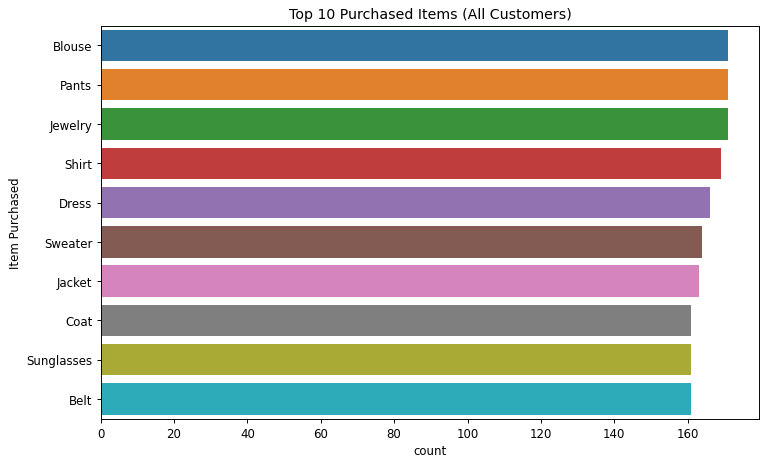

In [11]:
# plot a horizontal bar chart of the top 10 items (all customers)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_all.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items (All Customers)")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

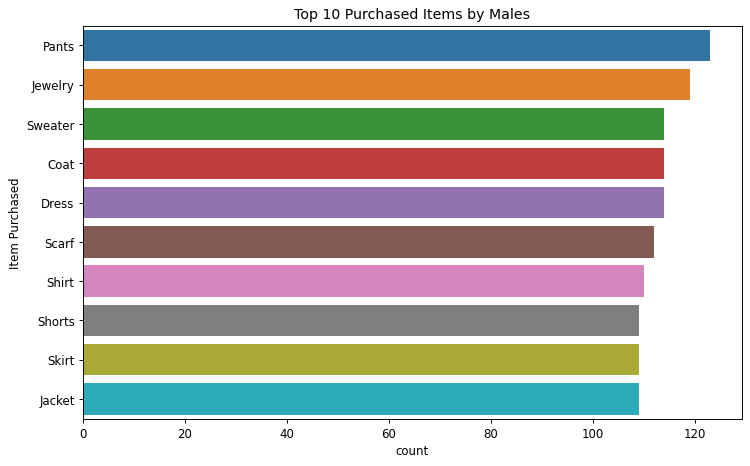

In [12]:
# plot a horizontal bar chart of the top 10 items for males
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_m.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

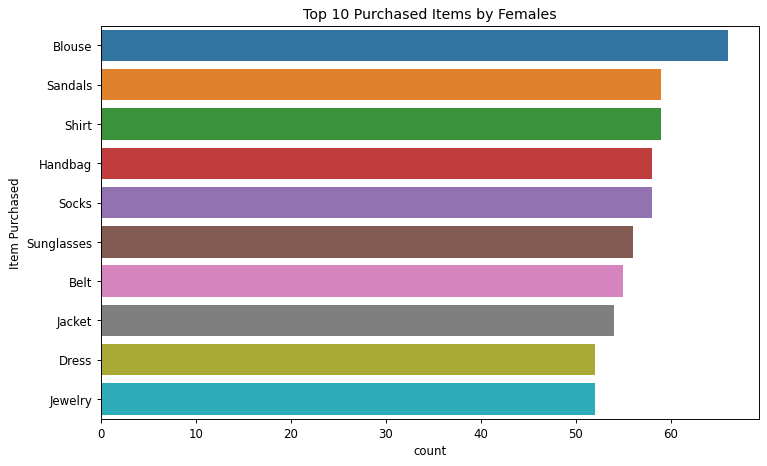

In [13]:
# plot a horizontal bar chart of the top 10 items for females
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [14]:
# count Size with value_counts() for all customers
df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [15]:
# count Size with value_counts() for male_df and female_df
print("Male:\n", male_df['Size'].value_counts())
print("\nFemale:\n", female_df['Size'].value_counts())

Male:
 Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

Female:
 Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [16]:
# count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [17]:
# count Category with value_counts().reset_index() for male_df and female_df
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_f = female_df['Category'].value_counts().reset_index()
print(ctg_m)
print(ctg_f)

      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


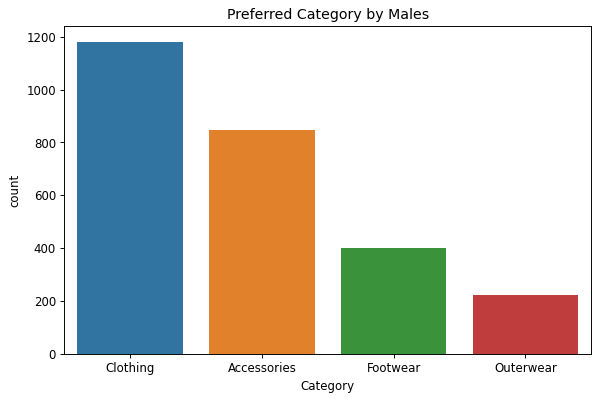

In [18]:
# plot a bar chart of preferred Category for males
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_m,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

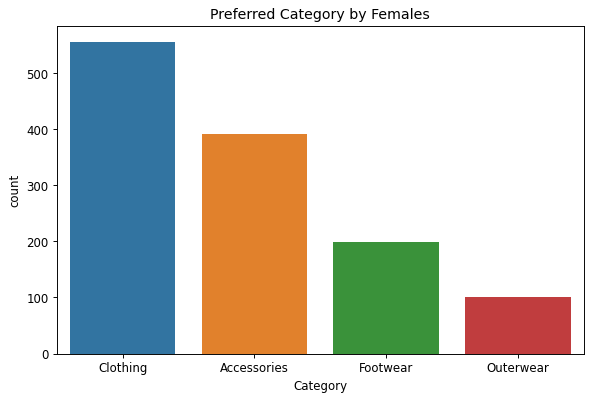

In [19]:
# plot a bar chart of preferred Category for females
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_f,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

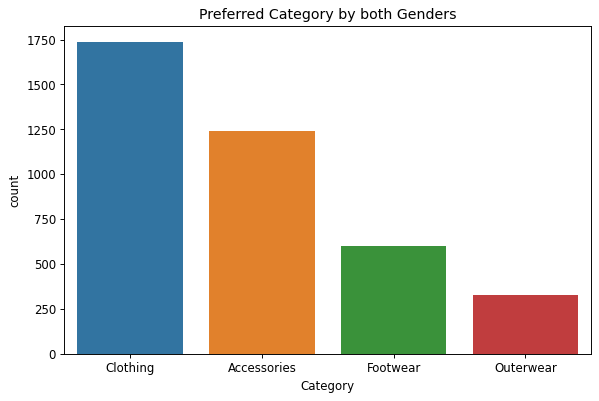

In [20]:
# plot a bar chart of preferred Category for both genders
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()

In [21]:
# create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

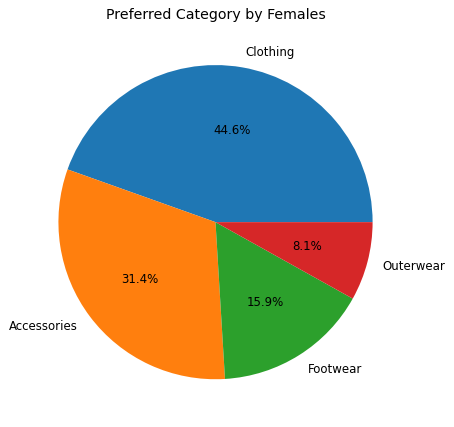

In [22]:
# plot a pie chart of preferred Category for females
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

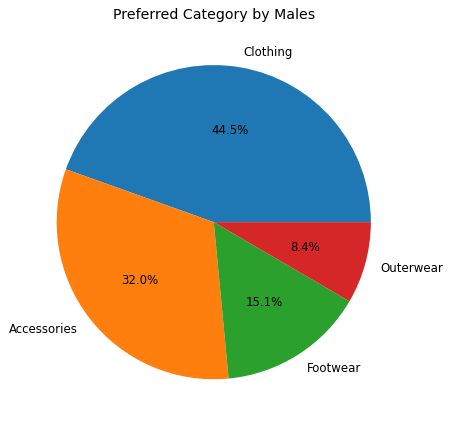

In [23]:
# plot a pie chart of preferred Category for males
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [24]:
# filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
avg_cr_f

np.float64(3.7044964028776977)

In [25]:
# filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
avg_cr_m

np.float64(3.7319220999153258)

In [26]:
avg_cr_m, avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

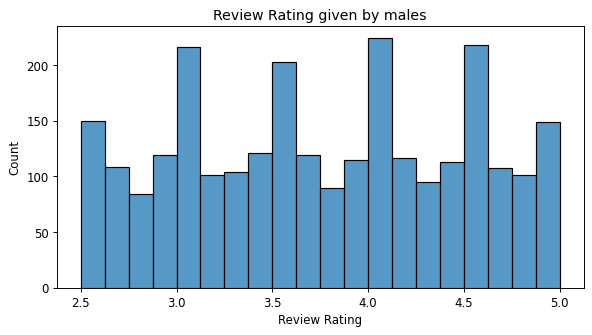

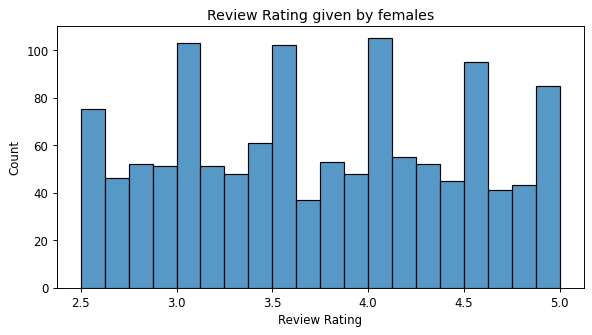

In [27]:
# plot Review Rating histograms for males and females
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [28]:
# count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [29]:
# sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

m_tpa, f_tpa

(np.int64(157890), np.int64(75191))

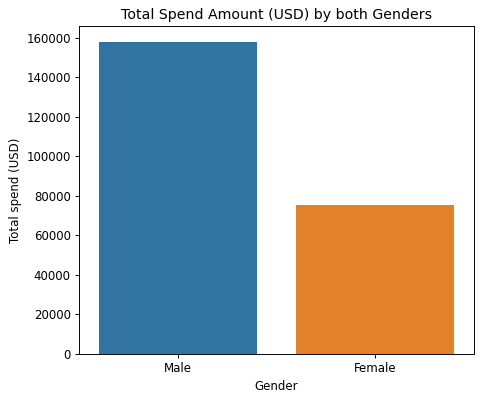

In [30]:
# plot total spend by gender
spend_df = pd.DataFrame({'Gender': ['Male', 'Female'], 'Total Spend': [m_tpa, f_tpa]})

plt.figure(figsize=(6, 5))
sns.barplot(
    data=spend_df,
    x='Gender',
    y='Total Spend',
    hue='Gender',
    dodge=False,
    legend=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [31]:
# filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [32]:
# filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [33]:
# create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

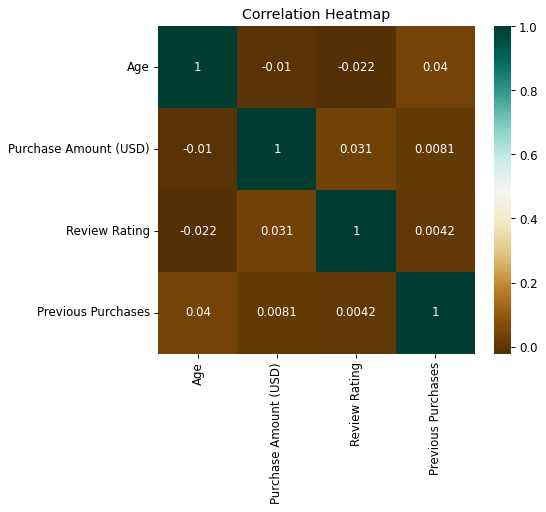

In [34]:
# correlation heatmap (Age, Purchase Amount (USD), Review Rating, Previous Purchases)
plt.figure(figsize=(6, 5))
c = df.corr(numeric_only=True)
sns.heatmap(c, annot=True, cmap="BrBG")
plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [35]:
# dummy variables for Gender, Size, and Category
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually,0,1,0,1,0,0,0,1,0,0


In [36]:
# MinMaxScaler on Purchase Amount (USD), StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax = MinMaxScaler()
standard = StandardScaler()

df['Amount_minmax'] = minmax.fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = standard.fit_transform(df[['Age']])

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [37]:
# bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=3, labels=['Low', 'Medium', 'High'])
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- **Quần áo** là danh mục hàng đầu đối với cả hai giới (1.181 đơn hàng của nam / 556 đơn hàng của nữ), theo sau là Phụ kiện, Giày dép và Áo khoác ngoài — thứ tự xếp hạng này giống nhau ở cả hai giới.
- Mặt hàng cụ thể được mua nhiều nhất có sự khác biệt giữa hai giới: **Quần** đối với nam (123 đơn hàng) và **Áo kiểu (blouse)** đối với nữ (66 đơn hàng), mặc dù danh sách 10 mặt hàng bán chạy nhất nhìn chung khá cân bằng về số lượng giữa các sản phẩm (~160-170 đơn hàng mỗi loại).
- Điểm đánh giá trung bình gần như tương đương giữa nam (**3,73**) và nữ (**3,70**) — giới tính dường như không ảnh hưởng đến cách khách hàng đánh giá sản phẩm họ đã mua.
- Tổng chi tiêu có sự chênh lệch lớn (157.890 USD ở nam so với 75.191 USD ở nữ), nhưng điều này chủ yếu là do **ảnh hưởng của quy mô mẫu** — có 2.652 dòng dữ liệu của nam so với 1.248 dòng của nữ. Mức chi tiêu trung bình *trên mỗi đơn hàng* gần như ngang nhau ở cả hai nhóm (~59,5 USD đối với nam và ~60,2 USD đối với nữ).
- Mã khuyến mãi được sử dụng trong **43%** số đơn hàng (1.677 trên tổng số 3.900), và bản đồ nhiệt tương quan cho thấy Độ tuổi, Điểm đánh giá và Lịch sử mua hàng đều có mối liên hệ rất yếu với Giá trị đơn hàng (tất cả đều có |r| < 0,05) — mức chi tiêu không biến động theo sát bất kỳ yếu tố nào trong số này ở tập dữ liệu hiện tại.

